GOAL: test the equations coupling and the variable timestep.

L'équation de dissolution d'un mineral traceur et de l'évolution des concentrations s'écrit:

$$
  \forall n \in [1, N-1], \left\{
    \begin{array}{l}
      \mathcal{A}_{i} \omega_{i} \dfrac{c_{i}^{n+1} - c_{i}^{n}}{\Delta t^{n}} = \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert \big(D_{e, ij}\dfrac{c_{j}^{n+1} - c_{i}^{n+1}}{ \left\lVert \overrightarrow{P_{i}P_{j}} \right\rVert}\big) - \mathcal{A}_{i} \omega_{i} \dfrac{\overline{c}_{i}^{n+1} - \overline{c}_{i}^{n}}{\Delta t^{n}}
      \\
      \overline{c}_{i}^{n+1} = \overline{c}_{i}^{n} + \Delta t^{n} k_{v} A_{s} \overline{c}_{i}^{n} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right)
    \end{array}
  \right.
$$

Note that this is strictly equivalent to :

$$
  \forall n \in [1, N-1], \left\{
    \begin{array}{l}
      c_{i}^{n+1} = c_{i}^{n} + \dfrac{\Delta t^{n}}{\mathcal{A}_{i} \omega_{i}} \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert \big(D_{e, ij}\dfrac{c_{j}^{n+1} - c_{i}^{n+1}}{ \left\lVert \overrightarrow{P_{i}P_{j}} \right\rVert}\big) - \overline{c}_{i}^{n+1} - \overline{c}_{i}^{n}
      \\
      \overline{c}_{i}^{n+1} = \overline{c}_{i}^{n} + \Delta t^{n} k_{v} A_{s} \overline{c}_{i}^{n} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right)
    \end{array}
  \right.
$$

However, the first system is more convinient because of the implicit scheme in the first equation. It is actually closer to the numerical implementation (in matrix form).

And the fixed point iteration criteria, $ \text{max} \left\lVert 1 - \dfrac{\overline{c}_{**}^{n}}{\overline{c}_{*}^{n}} \right\rVert  < \epsilon $, with $\overline{c}_{**}^{n}$ and $\overline{c}_{*}^{n}$ the immobile concentrations at the last and before last fixed point iterations.


$$ \mathcal{L} = \dfrac{1}{2} \sum_{n=0}^{N} \sum_{i} \left( \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\sigma_{c_{i}^{n, \mathrm{obs}}}}\right)^{2} - \langle \lambda_{c_{i}^{n+1}}, g_{c} \rangle - \langle \lambda_{\overline{c}_{i}^{n+1}}, g_{\overline{c}} \rangle $$

Explicitely it reads:

\begin{equation}
\begin{aligned}
\mathcal{L} = &\dfrac{1}{2} \sum_{n=0}^{N+1} \sum_{i} \left( \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\sigma_{c_{i}}^{n, \mathrm{obs}}}\right)^{2} 
\\
&- \sum_{n=0}^{N} \lambda_{c_{i}}^{n+1}\Bigg[\mathcal{A}_{i} \omega_{i} \dfrac{c_{i}^{n+1} - c_{i}^{n}}{\Delta t^{n}} - \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert \big(D_{e, ij}\dfrac{c_{j}^{n+1} - c_{i}^{n+1}}{ \left\lVert \overrightarrow{P_{i}P_{j}} \right\rVert}\big) + \mathcal{A}_{i} \omega_{i} \dfrac{\overline{c}_{i}^{n+1} - \overline{c}_{i}^{n}}{\Delta t^{n}} \Bigg]
\\
&- \sum_{n=0}^{N} \lambda_{\overline{c}_{i}}^{n+1} \Bigg[\overline{c}_{i}^{n+1} - \overline{c}_{i}^{n} - \Delta t^{n} k_{v} A_{s} \overline{c}_{i}^{n} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right)
 \Bigg]  
\end{aligned}
\end{equation}

## 1) Derivation by $\overline{c}_{i}^{n}$:

$$
\dfrac{\partial \mathcal{L}}{\partial \overline{c}_{i}^{n}} =
\begin{cases}
    \dfrac{\mathcal{A}_{i} \omega_{i}}{\Delta t^{0}} \lambda_{c_{i}}^{1} + \lambda_{\overline{c}_{i}}^{1} \left( 1 + \Delta t^{0} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{1}}{K_{s}}\right) \right) , & \text{if}\ n = 0 
    \\\\
    \mathcal{A}_{i} \omega_{i} \left(\dfrac{\lambda_{c_{i}}^{n+1}}{\Delta t^{n}} - \dfrac{\lambda_{c_{i}}^{n}}{\Delta t^{n-1}}\right) + \lambda_{\overline{c}_{i}}^{n+1} - \lambda_{\overline{c}_{i}}^{n} + \lambda_{\overline{c}_{i}}^{n+1} \Delta t^{n} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right) , & \forall n \in [1, N] 
    \\\\
    - \lambda_{\overline{c}_{i}}^{N+1} - \dfrac{\mathcal{A}_{i} \omega_{i}}{\Delta t^{N}}  \lambda_{c_{i}}^{N+1}, & \text{if}\ n = N+1
\end{cases}
$$

Since we want to impose $\dfrac{\partial \mathcal{L}}{\partial \overline{c}_{i}^{n}} = 0$, it gives the initial condition for the adjoint state:

$$ \lambda_{\overline{c}_{i}}^{N+1} =  - \dfrac{\mathcal{A}_{i} \omega_{i}}{\Delta t^{N}} \lambda_{c_{i}}^{N+1}$$

And the temporal evolution, $\mathcal{A}_{i} \omega_{i} \left(\dfrac{\lambda_{c_{i}}^{n}}{\Delta t^{n-1}} - \dfrac{\lambda_{c_{i}}^{n+1}}{\Delta t^{n}}\right)$ being an "adjoint transport" error source term:

$$\lambda_{\overline{c}_{i}}^{n} = \lambda_{\overline{c}_{i}}^{n+1} \left(1 + \Delta t^{n} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right) \right) - \mathcal{A}_{i} \omega_{i} \left(\dfrac{\lambda_{c_{i}}^{n}}{\Delta t^{n-1}} - \dfrac{\lambda_{c_{i}}^{n+1}}{\Delta t^{n}}\right), \forall n \in [1, N] $$


## 2) Derivation by $c_{i}^{2n}$:


\begin{equation}
\begin{aligned}
\mathcal{L} = &\dfrac{1}{2} \sum_{n=0}^{N+1} \sum_{i} \left( \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\sigma_{c_{i}}^{n, \mathrm{obs}}}\right)^{2} 
\\
&- \sum_{n=0}^{N} \lambda_{c_{i}}^{n+1}\Bigg[\mathcal{A}_{i} \omega_{i} \dfrac{c_{i}^{n+1} - c_{i}^{n}}{\Delta t^{n}} - \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert \big(D_{e, ij}\dfrac{c_{j}^{n+1} - c_{i}^{n+1}}{ \left\lVert \overrightarrow{P_{i}P_{j}} \right\rVert}\big) + \mathcal{A}_{i} \omega_{i} \dfrac{\overline{c}_{i}^{n+1} - \overline{c}_{i}^{n}}{\Delta t^{n}} \Bigg]
\\
&- \sum_{n=0}^{N} \lambda_{\overline{c}_{i}}^{n+1} \Bigg[\overline{c}_{i}^{n+1} - \overline{c}_{i}^{n} - \Delta t^{n} k_{v} A_{s} \overline{c}_{i}^{n} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right)
 \Bigg]  
\end{aligned}
\end{equation}

$$
\dfrac{\partial \mathcal{L}}{\partial c_{i}^{2n}} =
\begin{cases}
    - \dfrac{c_{i}^{0, \mathrm{obs}} - c_{i}^{0, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{0, \mathrm{obs}}\right)^{2}} + \dfrac{\mathcal{A}_{i} \omega_{i}}{\Delta t^{0}} \lambda_{c_{i}}^{1}, & \text{if}\ n = 0 
    \\\\
    - \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{n, \mathrm{obs}}\right)^{2}} + \mathcal{A}_{i} \omega_{i} \left(\dfrac{\lambda_{c_{i}}^{n+1}}{\Delta t^{n}} - \dfrac{\lambda_{c_{i}}^{n}}{\Delta t^{n-1}}\right) + \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert \big(D_{e, ij}\dfrac{\lambda_{c_{j}}^{n} - \lambda_{c_{i}}^{n}}{ \left\lVert \overrightarrow{P_{i}P_{j}} \right\rVert}\big) - \lambda_{\overline{c}_{i}}^{n} \Delta t^{n-1} k_{v} A_{s} \dfrac{\overline{c}_{i}^{n-1}}{Ks} , & \forall n \in [1, N] 
    \\\\
    - \dfrac{c_{i}^{N+1, \mathrm{obs}} - c_{i}^{N+1, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{N+1, \mathrm{obs}}\right)^{2}} - \lambda_{c_{i}}^{N+1} - \lambda_{\overline{c}_{i}}^{N+1} \Delta t^{N} k_{v} A_{s} \dfrac{\overline{c}_{i}^{N}}{Ks}, & \text{if}\ n = N+1
\end{cases}
$$

In addition to the gradient on the initial mobile concentration, we obtain the initial condition on the adjoint variable:

$$ \lambda_{c_{i}}^{N+1} = - \dfrac{c_{i}^{N+1, \mathrm{obs}} - c_{i}^{N+1, \mathrm{calc}}}{ \left(\sigma_{c_{i}}^{N+1, \mathrm{obs}}\right)^{2}} - \lambda_{\overline{c}_{i}}^{N+1} \Delta t^{N} k_{v} A_{s} \dfrac{\overline{c}_{i}^{N}}{Ks}$$

So we also have a fixed point system for the initial conditions. But it can be solved analytically using the fact that $$ \lambda_{\overline{c}_{i}}^{N+1} =  - \dfrac{\mathcal{A}_{i} \omega_{i}}{\Delta t^{N}} \lambda_{c_{i}}^{N+1}$$:

$$\implies \lambda_{c_{i}}^{N+1} = - \dfrac{c_{i}^{N+1, \mathrm{obs}} - c_{i}^{N+1, \mathrm{calc}}}{ \left(\sigma_{c_{i}}^{N+1, \mathrm{obs}}\right)^{2}} + \lambda_{c_{i}}^{N+1} \dfrac{\mathcal{A}_{i} \omega_{i}}{\Delta t^{N}} \Delta t^{N} k_{v} A_{s} \dfrac{\overline{c}_{i}^{N}}{Ks}$$

$$\implies \lambda_{c_{i}}^{N+1} = - \dfrac{c_{i}^{N+1, \mathrm{obs}} - c_{i}^{N+1, \mathrm{calc}}}{ \left(\sigma_{c_{i}}^{N+1, \mathrm{obs}}\right)^{2}} \dfrac{1}{1 - \mathcal{A}_{i} \omega_{i} k_{v} A_{s} \dfrac{\overline{c}_{i}^{N}}{Ks}}$$

- And the temporal evolution

$$ \mathcal{A}_{i} \omega_{i} \left(\dfrac{\lambda_{c_{i}}^{n}}{\Delta t^{n-1}} - \dfrac{\lambda_{c_{i}}^{n+1}}{\Delta t^{n}}\right) = \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert \big(D_{e, ij}\dfrac{\lambda_{c_{j}}^{n} - \lambda_{c_{i}}^{n}}{ \left\lVert \overrightarrow{P_{i}P_{j}} \right\rVert}\big) - \lambda_{\overline{c}_{i}}^{n} \Delta t^{n-1} k_{v} A_{s} \dfrac{\overline{c}_{i}^{n-1}}{Ks} - \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{n, \mathrm{obs}}\right)^{2}}, \forall n \in [1, N]$$

## Summary

And the fixed point iteration criteria, $ \text{max} \left\lVert 1 - \dfrac{\lambda_{\overline{c}_{**}}^{n}}{\lambda_{\overline{c}_{*}}^{n}} \right\rVert  < \epsilon $, with $\lambda_{{c, **}}^{n}$ and $\lambda_{c, *}^{n}$ the mobile adjoint concentrations at the last and before last adjoint fixed point iterations.


$$
\begin{cases}
    \lambda_{c_{i}}^{N+1} = - \dfrac{c_{i}^{N+1, \mathrm{obs}} - c_{i}^{N+1, \mathrm{calc}}}{ \left(\sigma_{c_{i}}^{N+1, \mathrm{obs}}\right)^{2}} \dfrac{1}{1 - \mathcal{A}_{i} \omega_{i} k_{v} A_{s} \dfrac{\overline{c}_{i}^{N}}{Ks}}, & \text{Initial condition}
    \\\\
    \lambda_{\overline{c}_{i}}^{N+1} =  - \dfrac{\mathcal{A}_{i} \omega_{i}}{\Delta t^{N}} \lambda_{c_{i}}^{N+1}, & \text{Initial condition}
    \\\\
    \lambda_{\overline{c}_{i}}^{n} = \lambda_{\overline{c}_{i}}^{n+1} \left(1 + \Delta t^{n} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right) \right) - \mathcal{A}_{i} \omega_{i} \left(\dfrac{\lambda_{c_{i}}^{n}}{\Delta t^{n-1}} - \dfrac{\lambda_{c_{i}}^{n+1}}{\Delta t^{n}}\right), & \forall n \in [1, N]
    \\\\
    \mathcal{A}_{i} \omega_{i} \left(\dfrac{\lambda_{c_{i}}^{n}}{\Delta t^{n-1}} - \dfrac{\lambda_{c_{i}}^{n+1}}{\Delta t^{n}}\right) = \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert \big(D_{e, ij}\dfrac{\lambda_{c_{j}}^{n} - \lambda_{c_{i}}^{n}}{ \left\lVert \overrightarrow{P_{i}P_{j}} \right\rVert}\big) - \lambda_{\overline{c}_{i}}^{n} \Delta t^{n-1} k_{v} A_{s} \dfrac{\overline{c}_{i}^{n-1}}{Ks} - \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{n, \mathrm{obs}}\right)^{2}}, & \forall n \in [1, N] 
\end{cases}
$$

The gradients with respect to the initial immobile and mobile concentrations read:

$$\dfrac{\partial \mathcal{L}}{\partial \overline{c}_{i}^{0}} = \dfrac{\mathcal{A}_{i} \omega_{i}}{\Delta t^{0}} \lambda_{c_{i}}^{1} + \lambda_{\overline{c}_{i}}^{1} \left( 1 + \Delta t^{0} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{1}}{K_{s}}\right) \right)$$

and

$$\dfrac{\partial \mathcal{L}}{\partial c_{i}^{0}} = - \dfrac{c_{i}^{0, \mathrm{obs}} - c_{i}^{0, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{0, \mathrm{obs}}\right)^{2}} + \dfrac{\mathcal{A}_{i} \omega_{i}}{\Delta t^{0}} \lambda_{c_{i}}^{1}$$

## Numerical tests

In [64]:
from typing import List, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
import numpy.typing as npt
import numdifftools as nd
import pyrtid.forward as dmfwd
from pyrtid.forward.models import (
    TransportModel,
    get_owner_neigh_indices,
    TransportParameters,
    GeochemicalParameters,
    Geometry,
    TimeParameters,
)
from pyrtid.inverse.adjoint.amodels import AdjointTransportModel
from pyrtid.utils import harmonic_mean, dxi_harmonic_mean, get_super_lu_preconditioner
from pyrtid.utils.finite_differences import finite_gradient

In [65]:
NDArrayFloat = npt.NDArray[np.float_]

In [78]:
nx = 20  # number of voxels along the x axis
ny = 1  # number of voxels along the y axis
dx = 2.98  # voxel dimension along the x axis
dy = 3.7  # voxel dimension along the y axis
dz = 1

geom = Geometry(nx, ny, dx, dy, dz)

# variable timestep
time_params = TimeParameters(
    nt=50,  # number of time steps
    dt_init=500.0,  # timestep in seconds
    dt_min=6000.0,
    dt_max=20000.0,
)

# Chemistry parameters
c0_ref = 0.0001  # general initial concentration [molal]
c0_est = 0.0002
M0 = 0.001  # mineral grade [mol/kg] -> kg of water
M1 = 0.0005  # mineral grade [mol/kg] -> kg of water
M1 = np.abs(0.001 * (0.5 + 0.5 * np.sin(np.arange(nx) / 2))).reshape(20, -1)

# To test with null mineral
# M0 = 0
# M1 = 0 * np.ones((nx, ny))

kv = -6.9e-9  # kinetic rate,       [mol/m2/s]
moleweight = 270.0  # molar weight [g/mol]
surface = 500  # cm2/g
As = moleweight * surface / 1e4  # specific area [m2/mol]
logK = 3.2
Ks = 1.0 / pow(10, logK)  # solubility constant [no unit]
diffusion = 0.05

gch_params_ref = GeochemicalParameters(c0_ref, M0, kv, As, Ks)

gch_params_est = GeochemicalParameters(c0_est, M1, kv, As, Ks)

tr_params = TransportParameters(diffusion=diffusion, is_numerical_acceleration=True)

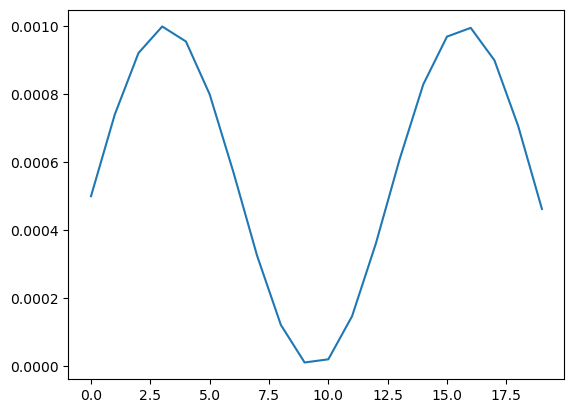

In [79]:
plt.plot(M1)

In [80]:
from scipy.sparse import csc_matrix, lil_matrix
from scipy.sparse.linalg import LinearOperator, splu, gmres


def make_transport_matrices_diffusion_only(
    geometry: dmfwd.Geometry,
    tr_model: TransportModel,
    time_params: dmfwd.TimeParameters,
) -> Tuple[csc_matrix, csc_matrix]:
    """
    Make matrices for the transport.

    Note
    ----
    Since the diffusion coefficient does not vary with time,
    matrices q_prev and q_next are the same.
    """

    dim = geometry.nx * geometry.ny
    q_prev = lil_matrix((dim, dim), dtype=np.float64)
    q_next = lil_matrix((dim, dim), dtype=np.float64)

    # X contribution
    if geometry.nx >= 2:
        dmean: NDArrayFloat = np.zeros((geometry.nx, geometry.ny), dtype=np.float64)
        dmean[:-1, :] = harmonic_mean(
            tr_model.effective_diffusion[:-1, :], tr_model.effective_diffusion[1:, :]
        )
        dmean = dmean.flatten(order="F")

        # Forward scheme:
        idc_owner, idc_neigh = get_owner_neigh_indices(
            geometry,
            (slice(0, geometry.nx - 1), slice(None)),
            (slice(1, geometry.nx), slice(None)),
            tr_model.cst_conc_indices,
        )

        q_next[idc_owner, idc_owner] += (
            tr_model.crank_nicolson_diffusion * dmean[idc_owner] / geometry.dx**2
        )
        q_next[idc_owner, idc_neigh] -= (
            tr_model.crank_nicolson_diffusion * dmean[idc_owner] / geometry.dx**2
        )
        q_prev[idc_owner, idc_owner] -= (
            (1.0 - tr_model.crank_nicolson_diffusion)
            * dmean[idc_owner]
            / geometry.dx**2
        )
        q_prev[idc_owner, idc_neigh] += (
            (1.0 - tr_model.crank_nicolson_diffusion)
            * dmean[idc_owner]
            / geometry.dx**2
        )

        # Backward scheme
        idc_owner, idc_neigh = get_owner_neigh_indices(
            geometry,
            (slice(1, geometry.nx), slice(None)),
            (slice(0, geometry.nx - 1), slice(None)),
            tr_model.cst_conc_indices,
        )

        q_next[idc_owner, idc_owner] += (
            tr_model.crank_nicolson_diffusion * dmean[idc_neigh] / geometry.dx**2
        )
        q_next[idc_owner, idc_neigh] -= (
            tr_model.crank_nicolson_diffusion * dmean[idc_neigh] / geometry.dx**2
        )
        q_prev[idc_owner, idc_owner] -= (
            (1.0 - tr_model.crank_nicolson_diffusion)
            * dmean[idc_neigh]
            / geometry.dx**2
        )
        q_prev[idc_owner, idc_neigh] += (
            (1.0 - tr_model.crank_nicolson_diffusion)
            * dmean[idc_neigh]
            / geometry.dx**2
        )

    # Y contribution
    if geometry.ny >= 2:
        dmean: NDArrayFloat = np.zeros((geometry.nx, geometry.ny), dtype=np.float64)
        dmean[:, :-1] = harmonic_mean(
            tr_model.effective_diffusion[:, :-1], tr_model.effective_diffusion[:, 1:]
        )
        dmean = dmean.flatten(order="F")

        # Forward scheme:
        idc_owner, idc_neigh = get_owner_neigh_indices(
            geometry,
            (slice(None), slice(0, geometry.ny - 1)),
            (slice(None), slice(1, geometry.ny)),
            tr_model.cst_conc_indices,
        )

        q_next[idc_owner, idc_owner] += (
            tr_model.crank_nicolson_diffusion * dmean[idc_owner] / geometry.dy**2
        )
        q_next[idc_owner, idc_neigh] -= (
            tr_model.crank_nicolson_diffusion * dmean[idc_owner] / geometry.dy**2
        )
        q_prev[idc_owner, idc_owner] -= (
            (1.0 - tr_model.crank_nicolson_diffusion)
            * dmean[idc_owner]
            / geometry.dy**2
        )
        q_prev[idc_owner, idc_neigh] += (
            (1.0 - tr_model.crank_nicolson_diffusion)
            * dmean[idc_owner]
            / geometry.dy**2
        )

        # Backward scheme
        idc_owner, idc_neigh = get_owner_neigh_indices(
            geometry,
            (slice(None), slice(1, geometry.ny)),
            (slice(None), slice(0, geometry.ny - 1)),
            tr_model.cst_conc_indices,
        )

        q_next[idc_owner, idc_owner] += (
            tr_model.crank_nicolson_diffusion * dmean[idc_neigh] / geometry.dy**2
        )
        q_next[idc_owner, idc_neigh] -= (
            tr_model.crank_nicolson_diffusion * dmean[idc_neigh] / geometry.dy**2
        )
        q_prev[idc_owner, idc_owner] -= (
            (1.0 - tr_model.crank_nicolson_diffusion)
            * dmean[idc_neigh]
            / geometry.dy**2
        )
        q_prev[idc_owner, idc_neigh] += (
            (1.0 - tr_model.crank_nicolson_diffusion)
            * dmean[idc_neigh]
            / geometry.dy**2
        )

    # Add 1/dt for the left term contribution
    q_next.setdiag(q_next.diagonal() + tr_model.porosity.flatten("F") / time_params.dt)
    q_prev.setdiag(q_prev.diagonal() + tr_model.porosity.flatten("F") / time_params.dt)

    return q_next.tocsc(), q_prev.tocsc()


def solve_transport(
    tr_model: TransportModel,
    geometry: Geometry,
    time_params: TimeParameters,
    time_index: int,
    nfpi: int,
) -> None:
    """
    Compute the transport problem.

    Parameters
    ----------
    tr_model: TransportModel
        The transport model.
    geometry: Geometry
        Geometry of the system.
    time_params: TimeParameters
        Time parameters of the system.
    time_index: int
        The iteration, or timestep id.
    nfpi:
        Number of fixed point iterations.
    """
    q_next, q_prev = make_transport_matrices_diffusion_only(
        geometry, tr_model, time_params
    )

    # Multiply prev matrix by prev vector
    tmp = q_prev.dot(tr_model.conc[:, :, time_index - 1].flatten(order="F"))

    # Chemical source term
    if tr_model.is_numerical_acceleration and nfpi == 1 and time_index != 1:
        dmdt = (
            tr_model.grade[:, :, time_index - 1] - tr_model.grade[:, :, time_index - 2]
        )
    else:
        dmdt = tr_model.grade[:, :, time_index] - tr_model.grade[:, :, time_index - 1]

    tmp -= (dmdt * geometry.mesh_area * tr_model.porosity / time_params.dt).ravel(
        order="F"
    )

    # Build the LU preconditioning
    preconditioner = get_super_lu_preconditioner(q_next)

    # Solve Ax = b with A sparse using LU preconditioner
    res, exit_code = gmres(
        q_next, tmp, x0=None, M=preconditioner, atol=tr_model.tolerance
    )

    # In that regard, we save the intermediate concentrations for the non
    # iterative sequential apprach (adjoint state)
    tr_model.conc[:, :, time_index] = res.reshape(geometry.ny, geometry.nx).T

    return exit_code


def solve_geochem(
    tr_model: TransportModel,
    gch_params: GeochemicalParameters,
    time_params: TimeParameters,
    time_index: int,
) -> None:
    """Compute the geochemistry part."""

    # Need to take into account boundary conditions:
    # And then the reactive (chemistry) contribution with the updated conc

    # Note: the concentration has been modified by the transport so we need to use the
    # updated one.
    # m0 = tr_model.grade_post_tr[:, :, time_index]
    m0 = tr_model.grade[:, :, time_index - 1]

    # The mobile concentration is from the transport
    dMdt = (
        gch_params.kv
        * gch_params.As
        * m0
        * (1.0 - tr_model.conc[:, :, time_index] / gch_params.Ks)
    )

    tr_model.grade[:, :, time_index] = m0 + dMdt * time_params.dt


def get_max_coupling_error(tr_model: TransportModel, time_index: int) -> float:
    """
    Return the maximum transport-chemistry coupling error.

    This error is evaluated from the immobile concentrations (mineral grades).
    """
    return float(
        np.nan_to_num(
            np.nanmax(
                np.abs(1 - tr_model.grade[:, :, time_index] / tr_model.grade_prev)
            ),
            nan=0.0,
        )
    )

In [81]:
tr_model_ref = TransportModel(geom, time_params, tr_params, gch_params_ref)
tr_model_ref.grade[:, :, 0] = M0
tr_model_est = TransportModel(geom, time_params, tr_params, gch_params_est)
tr_model_est.grade[:, :, 0] = M1


def solve_forward(
    _time_params: TimeParameters,
    _gch_params: GeochemicalParameters,
    _tr_model: TransportModel,
    geometry: Geometry,
    is_verbose: bool = False,
) -> None:
    _time_params.reset_dt()
    # Otherwise there is an issue
    for it in range(1, _time_params.nt + 1):
        nfpi = 1  # number of coupling (Fixed Point) iterations
        # Do not update the timestep for the first iteration
        # update the timestep based on the convergence speed.
        if it != 1:
            _time_params.update_dt(nfpi)
        # Convergence flag
        has_converged = False

        # Copy the grades (To place in another function afterwards)
        _tr_model.grade[:, :, it] = _tr_model.grade[:, :, it - 1]

        # Iterate the chemistry transport system while the convergence is no meet
        while not has_converged:
            # Save the grade for the fix point iterations
            _tr_model.grade_prev = _tr_model.grade[:, :, it].copy()

            solve_transport(_tr_model, geometry, _time_params, it, nfpi)
            solve_geochem(_tr_model, _gch_params, time_params, it)

            # One more coupling iteration has been performed

            if is_verbose:
                print(
                    f"max-coupling error at it = {it}-{nfpi}: {get_max_coupling_error(_tr_model, it)}"
                )
            has_converged = get_max_coupling_error(_tr_model, it) < _tr_model.fpi_eps
            if is_verbose:
                print(f"has-converged ?: {has_converged}")

            # Update the number of FPI
            nfpi += 1


solve_forward(time_params, gch_params_ref, tr_model_ref, geom, is_verbose=True)
solve_forward(time_params, gch_params_est, tr_model_est, geom)

max-coupling error at it = 1-1: 0.00047032031947347175
has-converged ?: False
max-coupling error at it = 1-2: 4.595683858577004e-06
has-converged ?: True
max-coupling error at it = 2-1: 0.00048423704556965763
has-converged ?: False
max-coupling error at it = 2-2: 1.8760318809540877e-07
has-converged ?: True
max-coupling error at it = 3-1: 0.0005030422441902882
has-converged ?: False
max-coupling error at it = 3-2: 2.0189704685869003e-07
has-converged ?: True
max-coupling error at it = 4-1: 0.0005223026112923801
has-converged ?: False
max-coupling error at it = 4-2: 2.1698257191005155e-07
has-converged ?: True
max-coupling error at it = 5-1: 0.0005420010344560078
has-converged ?: False
max-coupling error at it = 5-2: 2.3285490158286848e-07
has-converged ?: True
max-coupling error at it = 6-1: 0.0005621168067693194
has-converged ?: False
max-coupling error at it = 6-2: 2.4949887067471366e-07
has-converged ?: True
max-coupling error at it = 7-1: 0.0005826253395152525
has-converged ?: Fals

max-coupling error at it = 16-2: 4.430753901552009e-07
has-converged ?: True
max-coupling error at it = 17-1: 0.0008005451046585454
has-converged ?: False
max-coupling error at it = 17-2: 4.6183642599118e-07
has-converged ?: True
max-coupling error at it = 18-1: 0.0008223533820703732
has-converged ?: False
max-coupling error at it = 18-2: 4.794354224735287e-07
has-converged ?: True
max-coupling error at it = 19-1: 0.0008438550453654381
has-converged ?: False
max-coupling error at it = 19-2: 4.954594523542966e-07
has-converged ?: True
max-coupling error at it = 20-1: 0.0008649516256288292
has-converged ?: False
max-coupling error at it = 20-2: 5.094375299385945e-07
has-converged ?: True
max-coupling error at it = 21-1: 0.0008855381444153876
has-converged ?: False
max-coupling error at it = 21-2: 5.208364293185497e-07
has-converged ?: True
max-coupling error at it = 22-1: 0.0009055032907768767
has-converged ?: False
max-coupling error at it = 22-2: 5.290568021454334e-07
has-converged ?: 

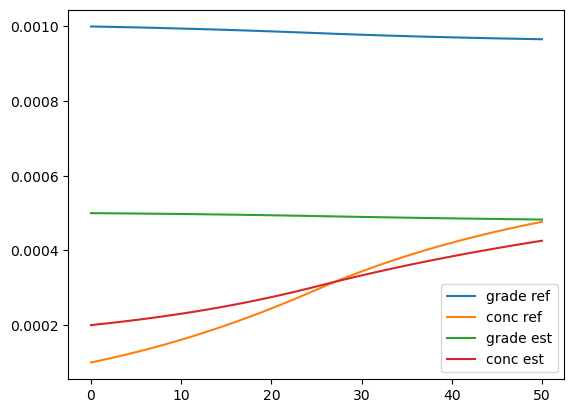

In [82]:
import matplotlib.pyplot as plt

plt.plot(tr_model_ref.grade[0, 0, :], label="grade ref")
plt.plot(tr_model_ref.conc[0, 0, :], label="conc ref")
plt.plot(tr_model_est.grade[0, 0, :], label="grade est")
plt.plot(tr_model_est.conc[0, 0, :], label="conc est")
plt.legend()

- Build an inverse

$$
\begin{cases}
    \lambda_{c_{i}}^{N+1} = - \dfrac{c_{i}^{N+1, \mathrm{obs}} - c_{i}^{N+1, \mathrm{calc}}}{ \left(\sigma_{c_{i}}^{N+1, \mathrm{obs}}\right)^{2}}, & \text{Initial condition}
    \\\\
    \lambda_{\overline{c}_{i}}^{N+1} = -\lambda_{c_{i}}^{N+1}, & \text{Initial condition}
    \\\\
    \lambda_{\overline{c}_{i}}^{n} = \lambda_{\overline{c}_{i}}^{n+1} \left(1 + \Delta t^{n} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right) \right) - \left(\lambda_{c_{i}}^{n} - \lambda_{c_{i}}^{n+1}\right), & \forall n \in [1, N]
    \\\\
    \lambda_{c_{i}}^{n} = \lambda_{c_{i}}^{n+1} (1 + D_{i}) - \lambda_{\overline{c}_{i}}^{n} \Delta t^{n-1} k_{v} A_{s} \dfrac{\overline{c}_{i}^{n-1}}{Ks} - \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{n, \mathrm{obs}}\right)^{2}}, & \forall n \in [1, N] 
\end{cases}
$$

In [83]:
def solve_adjoint_geochem(
    tr_model: TransportModel,
    atr_model: AdjointTransportModel,
    gch_params: GeochemicalParameters,
    time_params: TimeParameters,
    time_index: int,
    nafpi: int,
    is_numerical_acceleration: bool = False,
) -> None:
    # Adjoint variables
    am_old = atr_model.a_grade[:, :, time_index + 1]
    ac_old = atr_model.a_conc[:, :, time_index + 1]
    ac_cur = atr_model.a_conc[:, :, time_index]
    # Forward variables
    c_old = tr_model.conc[:, :, time_index + 1]
    # Timesteps
    dt_cur = time_params.ldt[time_index]

    # Update mineral value
    atr_model.a_grade[:, :, time_index] = am_old * (
        1 + gch_params.kv * gch_params.As * (1.0 - c_old / gch_params.Ks) * dt_cur
    ) - (
        ac_cur - ac_old
    )  # transport adjoint source term


def solve_adjoint_transport(
    tr_model: TransportModel,
    atr_model: AdjointTransportModel,
    gch_params: GeochemicalParameters,
    a_sources: NDArrayFloat,
    time_index: int,
) -> None:
    # This works
    ac_old = atr_model.a_conc[:, :, time_index + 1]

    # Update mineral value
    atr_model.a_conc[:, :, time_index] = (
        ac_old * (1 - tr_model.diffusion)
        - atr_model.a_grade[:, :, time_index]
        * time_params.ldt[time_index - 1]
        * gch_params.kv
        * gch_params.As
        * (tr_model.grade[:, :, time_index - 1] / gch_params.Ks)
        - a_sources[:, :, time_index]
    )


def get_adjoint_max_coupling_error(
    atr_model: AdjointTransportModel, time_index: int
) -> float:
    """
    Return the maximum transport-chemistry coupling error.

    This error is evaluated from the immobile concentrations (mineral grades).
    """
    return float(
        np.nan_to_num(
            np.max(
                np.abs(1 - atr_model.a_conc[:, :, time_index] / atr_model.a_conc_prev)
            ),
            nan=0.0,
        )
    )

In [84]:
def get_a_sources(
    tr_model_ref: TransportModel, tr_model_est: TransportModel
) -> NDArrayFloat:
    _out = tr_model_ref.conc - tr_model_est.conc
    # Modify here to remove some of the adjoint variables
    # _out[:, :, 2:] = 0.0
    return _out


def solve_adjoint_system(
    _time_params: TimeParameters,
    _gch_params: GeochemicalParameters,
    _tr_model: TransportModel,
    geometry: Geometry,
    is_verbose: bool = False,
) -> AdjointTransportModel:
    # Build an adjoint model
    atr_model = AdjointTransportModel(geometry, time_params, _gch_params)

    # Add the adjoint sources
    _a_sources = get_a_sources(tr_model_ref, tr_model_est)
    atr_model.a_conc[:, :, -1] -= _a_sources[:, :, -1]
    atr_model.a_grade[:, :, -1] = -atr_model.a_conc[
        :, :, -1
    ]  # no observable for mineral

    # print(_a_sources[:, :, -1])

    # Otherwise there is an issue
    for it in range(time_params.nt - 1, 0, -1):
        nafpi = 1  # number of coupling (Fixed Point) iterations
        # Convergence flag for the adjoint
        has_converged = False

        # Copy the grades (To place in another function afterwards)
        atr_model.a_conc[:, :, it] = atr_model.a_conc[:, :, it + 1]

        # print(atr_model.a_conc[:, :, it])

        # Iterate the chemistry transport system while the convergence is no meet
        while not has_converged:
            # Save the grade for the fix point iterations
            atr_model.a_conc_prev = atr_model.a_conc[:, :, it].copy()

            solve_adjoint_geochem(
                _tr_model,
                atr_model,
                _gch_params,
                time_params,
                it,
                nafpi,
                is_numerical_acceleration=True,
            )

            # print(atr_model.a_grade[:, :, it])
            # print(atr_model.a_conc_prev)

            solve_adjoint_transport(_tr_model, atr_model, _gch_params, _a_sources, it)

            # One more coupling iteration has been performed

            if is_verbose:
                print(
                    f"max-coupling error at it = {it}-{nafpi}: {get_adjoint_max_coupling_error(atr_model, it)}"
                )
            has_converged = get_adjoint_max_coupling_error(atr_model, it) < 1e-10
            if is_verbose:
                print(f"has-converged ?: {has_converged}")

            # Update the number of FPI
            nafpi += 1
    return atr_model


atr_model = solve_adjoint_system(
    time_params, gch_params_est, tr_model_est, geom, is_verbose=True
)

max-coupling error at it = 49-1: 0.9304842901234118
has-converged ?: False
max-coupling error at it = 49-2: 0.0013719048097983189
has-converged ?: False
max-coupling error at it = 49-3: 3.916963540406826e-06
has-converged ?: False
max-coupling error at it = 49-4: 1.1168045155329764e-08
has-converged ?: False
max-coupling error at it = 49-5: 3.184252861387904e-11
has-converged ?: True
max-coupling error at it = 48-1: 0.44698395633081733
has-converged ?: False
max-coupling error at it = 48-2: 0.0008790828760422142
has-converged ?: False
max-coupling error at it = 48-3: 2.5102318650382927e-06
has-converged ?: False
max-coupling error at it = 48-4: 7.16167836145587e-09
has-converged ?: False
max-coupling error at it = 48-5: 2.0432322500596456e-11
has-converged ?: True
max-coupling error at it = 47-1: 0.285334314034404
has-converged ?: False
max-coupling error at it = 47-2: 0.000631223951119475
has-converged ?: False
max-coupling error at it = 47-3: 1.8031739539292602e-06
has-converged ?: F

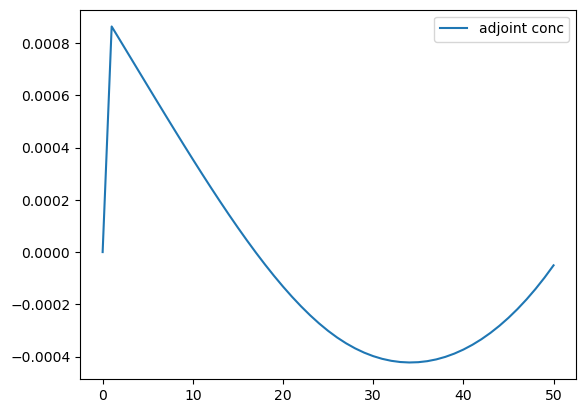

In [85]:
plt.plot(atr_model.a_conc[0, 0, :], label="adjoint conc")
plt.legend()

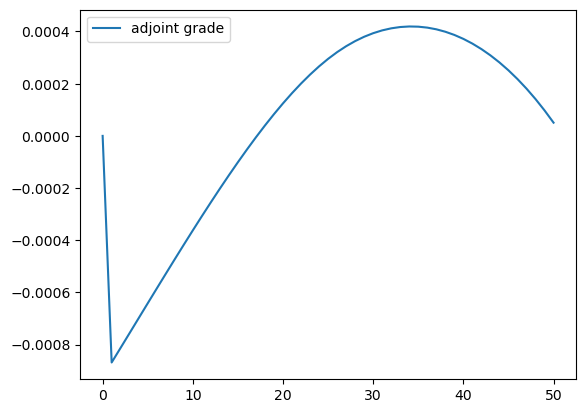

In [86]:
plt.plot(atr_model.a_grade[0, 0, :], label="adjoint grade")
plt.legend()

# Gradient computation

$$\dfrac{\partial \mathcal{L}}{\partial \overline{c}_{i}^{0}} = \lambda_{c_{i}}^{2} + \lambda_{\overline{c}_{i}}^{2} \left( 1 + \Delta t^{0} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{0}(1+D_{i})}{K_{s}}\right) \right)$$

$$\dfrac{\partial \mathcal{L}}{\partial \overline{c}_{i}^{0}} = \lambda_{c_{i}}^{1} + \lambda_{\overline{c}_{i}}^{1} \left( 1 + \Delta t^{0} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{1}}{K_{s}}\right) \right)$$

In [87]:
gch_params = gch_params_est


def get_gradient(time_params: TimeParameters):
    return atr_model.a_conc[:, :, 1] + atr_model.a_grade[:, :, 1] * (
        1
        + time_params.ldt[0]
        * gch_params.kv
        * gch_params.As
        * (1.0 - tr_model_est.conc[:, :, 1] / gch_params.Ks)
    )


adjoint_gradient = get_gradient(time_params=time_params).ravel()
adjoint_gradient

array([-4.26027867e-06, -4.18850715e-06, -4.13919959e-06, -4.13043729e-06,
       -4.16994463e-06, -4.25368582e-06, -4.36651616e-06, -4.48499919e-06,
       -4.58248511e-06, -4.63583983e-06, -4.63204469e-06, -4.57220210e-06,
       -4.47118925e-06, -4.35311886e-06, -4.24456762e-06, -4.16800873e-06,
       -4.13705602e-06, -4.15398064e-06, -4.20936479e-06, -4.28381755e-06])

- Objective function definition

In [88]:
def objfun(x, time_params: TimeParameters) -> float:
    _tr_model = TransportModel(time_params.nt, gch_params_est, tr_params)
    _tr_model.grade[:, :, 0] = x.reshape(nx, ny, order="F")
    solve_forward(time_params, gch_params_est, _tr_model, is_verbose=False)

    _a_sources = get_a_sources(tr_model_ref, _tr_model)
    return float(0.5 * np.sum(_a_sources**2))

- Evaluate the objective function for the initial guess

In [89]:
objfun(M1, time_params)

TypeError: TransportModel.__init__() missing 1 required positional argument: 'gch_params'

- Define a step for the finite differences

In [ ]:
import sys

eps = sys.float_info.epsilon * 1e6
eps

2.220446049250313e-10

- We check the gradients by finite differences (with pyrtid and numdifftools, it is supposed to give the same results, the main difference is that pyrtid supports parallel running.)

In [ ]:
def objfun_wrapper(x: NDArrayFloat) -> float:
    return objfun(x, time_params)


fd_gradient_numdifftools = nd.Gradient(objfun_wrapper, step=eps)(M1.ravel("F"))
fd_gradient_pyrtid = finite_gradient(
    np.array([M1]).ravel("F"), objfun, fm_args=(time_params,), eps=eps
)

- Plot the gradients

In [ ]:
adjoint_gradient / fd_gradient_pyrtid

array([1.00049416, 1.00117497, 0.99969   , 1.0001932 , 0.9999839 ,
       1.00224329, 1.00060198, 1.0002919 , 1.00010288, 1.00000928,
       1.00001699, 1.00012535, 1.00032874, 1.00067189, 1.00640837,
       1.00006539, 1.00017814, 0.99934217, 1.00097148, 1.00044517])

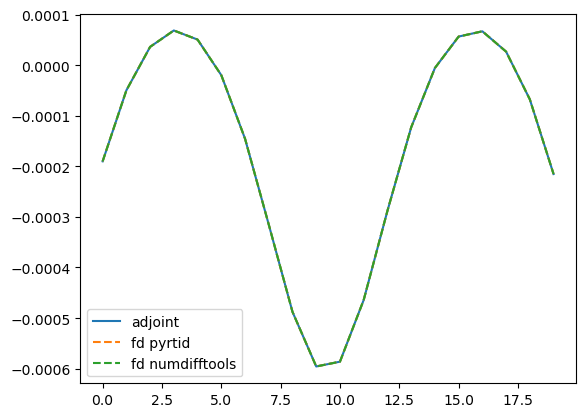

In [ ]:
plt.plot(adjoint_gradient, label="adjoint")
plt.plot(fd_gradient_pyrtid, label="fd pyrtid", linestyle="--")
plt.plot(fd_gradient_numdifftools, label="fd numdifftools", linestyle="--")
plt.legend()

- Plot the residuals

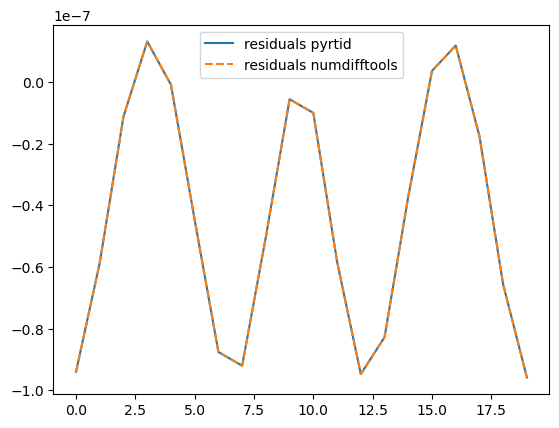

In [ ]:
plt.plot((adjoint_gradient - fd_gradient_pyrtid), label="residuals pyrtid")
plt.plot(
    (adjoint_gradient - fd_gradient_numdifftools),
    linestyle="--",
    label="residuals numdifftools",
)
plt.legend()